In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler
import tqdm as notebook_tqdm
from torch.nn import BCEWithLogitsLoss

import monk_common as mc
import nn_common as nnc
import cross_common as cr
import torch
from torch import nn
import importlib
from functools import partial
import copy
from nn_common import FeatureTargetSet, HoldOutStrategy, EarlyStoppingStrategy
from cross_common import EPOCHS_VL_MSE,FOLD_VL_MSE,FOLD_TR_MSE
from cross_common import MEE,MSE,RMSE,MAE,ACC
from cross_common import (FOLD_VL_CUSTOM, FOLD_TR_CUSTOM)


importlib.reload(nnc)
importlib.reload(mc)
importlib.reload(cr)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h1>NN - Optuna</h1>
<h2>Exploring the cup dataset with NN Classifier with the help of Optuna tools.</h2>
<p>This notebook serves the purpose of exploring the hypotesis space by manually varying the hyperparameters and for inspecting the whole pipeline.</p>
<hr/>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [3]:
monk_data_set_id = 3
df_train, df_test = mc.load_set(monk_data_set_id)
# Scaler
scaler = StandardScaler()
X_tr, y_tr = mc.split_and_prepare_dataset(df_train)
X_ts, y_ts = mc.split_and_prepare_dataset(df_test)
mc.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,122,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 60","class 0 = 204, class 1 = 228"


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [4]:

# Set to True when model is selcted and assessed
dump_prediction = False

# The seed to be used by data splitter
default_state = 42
default_seed = 1

torch.manual_seed(default_seed)

# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 1

# fold strategy
base_fold_strategy = cr.common_fold_strategy(stratified=True, n_split=3)

default_batch_size = 20

# ----- Defining model basic architecture --------
base_hidden_layers = ["4"]

# The output and loss function, must be changed according to the type of task
loss_function = BCEWithLogitsLoss() #nn.MSELoss
# activation function
base_activation_function = ["relu"]
output_adapter = nnc.binary_bce_adapter()
# ------------------------------------------


# ------------ Learning rate ---------------
base_weight_decay = [0]
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-3 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------


# -- The metrics to compute during training -
epochs_metrics_dict = {
    cr.LOSS: (loss_function,min)
}
# -------------------------------------------


# ---------- Learning rate decay -----------
# The factor by which learning rate will decrease
learning_rate_decay_factor = 0.5    #0.6 #0.5
# The epoch to wait before applying the rate decay factor (must be lower than early stopping)
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2 #1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


In [5]:
def objective(trial, X, y, trial_dict, objective_function, seed=default_seed):
    """
    Main objective function to be used with Optuna search.
    :param trial: the optuna trial object
    :param X: the feature
    :param y: the target
    :param trial_dict: the configuration dictionary
    :param objective_function: the objective function
    :return:
    """
    # seed for reproducibility
    torch.manual_seed(seed)

    epochs_trial = trial_dict["epochs"]
    batch_size_trial = trial_dict["batch_size"]
    fold_strategy_trial = trial_dict["fold_strategy"]
    output_adapter_trial = trial_dict["output_adapter"]
    scheduler_template_trial = trial_dict.get("scheduler_template",None)
    hidden_layers_raw = nnc.suggest_trial_param(trial, "hidden_layers", trial_dict["hidden_layers"])
    hidden_layers_trial = [int(x) for x in hidden_layers_raw.split(",")]
    activation_trial = nnc.suggest_trial_param(trial,"activation", trial_dict["activation"])
    learning_rate_trial = nnc.suggest_trial_param(trial, "learning_rate", trial_dict["learning_rate"])
    weight_decay_trial = nnc.suggest_trial_param(trial, "weight_decay", trial_dict["weight_decay"])
    metrics_trial = trial_dict.get("metrics", None)
    net_trial = nnc.build_nn_net(input_dimension, output_dimension, list(hidden_layers_trial), activation_trial)
    #model_trial = nnc.MLP(net_trial, output_adapter_trial)

    #init_method = "kaiming" if activation_trial == "relu" else "xavier"
    #init_nonlinearity = "relu" if activation_trial == "relu" else "tanh"
    #model_trial.apply(lambda m: nnc.init_weights(m, method="kaiming", nonlinearity="relu"))
    model_trial = nnc.build_nn_model(net_trial, output_adapter_trial)

    optimizer_template_trial = partial(
        torch.optim.AdamW,
        lr=learning_rate_trial,
        weight_decay=weight_decay_trial,
        betas=(0.95, 0.999)
    )

    inner_train_params_trial = {
        "epochs": epochs_trial,
        "batch_size": batch_size_trial,
        "scheduler_template": scheduler_template_trial,
        "optimizer_template": optimizer_template_trial,
        "loss_function": loss_function,
        "early_stopping_strategy": early_stopping_strategy,
        "silence_output": True,
        "metrics": metrics_trial,
    }

    return objective_function(
        nnc.kfold(model_trial, X, y, fold_strategy_trial, inner_train_params_trial)
    )


<h3>Optuna</h3>

<h4>Learning Rate</h4>
<hr>

<h5>Preparation</h5>

In [6]:

# partially instantiate evaluation funtion
evaluate_lr_partial = partial(
    mc.evaluate_lr,
    epoch_metric=cr.EPOCHS_VL_LOSS,
    fold_metric=cr.FOLD_VL_LOSS,
    early_epoch=30
)

#coarse_learning_rates = [1e-4, 5e-4, 1e-3, 2e-3, 3e-3]
coarse_learning_rates = [1e-4, 5e-4, 1e-3, 3e-3, 5e-3, 1e-2]

<h5>Coarse Grained</h5>

In [7]:
importlib.reload(nnc)
importlib.reload(mc)
# as we are testing few lr a small
# nr of trials is enough
coarse_grained_trials_nr = 20

default_epochs = 500
objective_coarse_grained_lr_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_lr_partial,
    trial_dict={
        "epochs": default_epochs,
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": coarse_learning_rates,
        "weight_decay": base_weight_decay,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict
    }
)

coarse_grained_lr_study = optuna.create_study(
    # see find_best_lr_from_trials for the reason why
    # we have adopted these directions
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)

coarse_grained_lr_study.optimize(objective_coarse_grained_lr_partial, show_progress_bar=True, n_trials=coarse_grained_trials_nr)

[I 2026-03-29 10:29:58,612] A new study created in memory with name: no-name-8e0f20e6-d5fd-4165-99da-178b6271e13d
  5%|▌         | 1/20 [00:01<00:26,  1.39s/it]

[I 2026-03-29 10:30:00,004] Trial 0 finished with values: [0.20971198361821294, 0.0048390802054288674] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.005, 'weight_decay': 0}.


 10%|█         | 2/20 [00:03<00:37,  2.06s/it]

[I 2026-03-29 10:30:02,544] Trial 1 finished with values: [0.25215579357331364, 0.0011354230635709547] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.001, 'weight_decay': 0}.


 15%|█▌        | 3/20 [00:06<00:41,  2.43s/it]

...

[I 2026-03-29 10:30:38,591] Trial 17 finished with values: [0.20971198361821294, 0.0048390802054288674] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.005, 'weight_decay': 0}.


 95%|█████████▌| 19/20 [00:42<00:02,  2.39s/it]

[I 2026-03-29 10:30:41,240] Trial 18 finished with values: [0.25215579357331364, 0.0011354230635709547] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.001, 'weight_decay': 0}.


100%|██████████| 20/20 [00:45<00:00,  2.28s/it]

[I 2026-03-29 10:30:44,198] Trial 19 finished with values: [0.6776681040845266, 0.00017111419963068407] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0001, 'weight_decay': 0}.


In [8]:
importlib.reload(mc)
coarse_grained_lr = mc.find_best_lr_from_trials(coarse_grained_lr_study)
print(f"lr: {coarse_grained_lr}")

lr: 0.005


<h5>Fine Grained</h5>

In [9]:
# the number of trials depends on the
# suggestion returned by optuna
fine_grained_trials_nr=30

# Build a fine-grained search range around the best coarse learning rate
# by scaling it with a constant factor (lr / factor, lr * factor).
# This refines the search locally on a logarithmic scale.
# if coarse lr = 0.001 --> interval = (0.00033 , 0.003)
# (optuna will return --> [0.00033, 0.00045,0.00060,0.00080,0.00105,0.00140,0.00190,0.00250,0.003] )
constant_lr_factor = 3
low_lr = coarse_grained_lr / constant_lr_factor
high_lr = coarse_grained_lr * constant_lr_factor


objective_fine_grained_lr_partial = partial(
    objective, X=X_tr, y=y_tr, objective_function = evaluate_lr_partial,
    trial_dict={
        "epochs": default_epochs,
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": (low_lr, high_lr),
        "weight_decay": base_weight_decay,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict
    }
)

fine_grained_lr_study = optuna.create_study(
    # same reason for "directions"
    directions=["maximize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_lr_study.optimize(objective_fine_grained_lr_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)

[I 2026-03-29 10:30:44,253] A new study created in memory with name: no-name-a9fc42df-b639-470d-823a-c098b46dfc2c
  3%|▎         | 1/30 [00:02<01:07,  2.32s/it]

[I 2026-03-29 10:30:46,575] Trial 0 finished with values: [0.23189947845005407, 0.0020827723568468456] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0019352219154353035, 'weight_decay': 0}.


  7%|▋         | 2/30 [00:04<01:04,  2.32s/it]

[I 2026-03-29 10:30:48,894] Trial 1 finished with values: [0.2407620342645219, 0.0019110478749574187] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0}.


 10%|█         | 3/30 [00:05<00:49,  1.82s/it]

...

[I 2026-03-29 10:31:18,930] Trial 27 finished with values: [0.22090471747929488, 0.00686607300722867] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0075620911685216246, 'weight_decay': 0}.


 97%|█████████▋| 29/30 [00:35<00:01,  1.13s/it]

[I 2026-03-29 10:31:19,553] Trial 28 finished with values: [0.21429843061823184, 0.010246964359917076] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.013824924865941706, 'weight_decay': 0}.


100%|██████████| 30/30 [00:37<00:00,  1.25s/it]

[I 2026-03-29 10:31:21,608] Trial 29 finished with values: [0.23070047371755772, 0.002450006309653489] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0022092153997601087, 'weight_decay': 0}.


In [10]:
final_lr = mc.find_best_lr_from_trials(fine_grained_lr_study)
print(coarse_grained_lr, final_lr)

0.005 0.0017898406757904646


<h4>Weight Decay</h4>
<hr>

<h5>Preparation</h5>

In [ ]:

evaluate_wd_partial = partial(
    nnc.metric_mean_and_gap_TR_VL,
    vl_key=cr.FOLD_VL_LOSS,
    tr_key=cr.FOLD_TR_LOSS,
)

#coarse_weight_decays = [0.0, 1e-5, 1e-4, 5e-4]
coarse_weight_decays = [0.0, 1e-6, 1e-5, 1e-4, 5e-4]

<h5>Coarse Grained</h5>

In [12]:
coarse_grained_wd_trials_nr = 20

objective_coarse_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict={
        "epochs": default_epochs,
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": [final_lr],
        "weight_decay": coarse_weight_decays,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict
    }
)

coarse_grained_wd_study = optuna.create_study(
    # minimize according to find_best_weight_decay_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
coarse_grained_wd_study.optimize(objective_coarse_grained_wd_partial, show_progress_bar=True, n_trials=coarse_grained_wd_trials_nr)

[I 2026-03-29 10:31:21,666] A new study created in memory with name: no-name-6bcdd477-49c0-4607-a735-ff448664f83d
  5%|▌         | 1/20 [00:02<00:46,  2.46s/it]

[I 2026-03-29 10:31:24,130] Trial 0 finished with values: [0.24070324839615242, 0.11915625787431623] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.0001}.


 10%|█         | 2/20 [00:04<00:43,  2.41s/it]

[I 2026-03-29 10:31:26,507] Trial 1 finished with values: [0.24070324839615242, 0.11915625787431623] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.0001}.


 15%|█▌        | 3/20 [00:07<00:40,  2.41s/it]

...

[I 2026-03-29 10:32:04,730] Trial 17 finished with values: [0.24070324839615242, 0.11915625787431623] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.0001}.


 95%|█████████▌| 19/20 [00:45<00:02,  2.37s/it]

[I 2026-03-29 10:32:07,074] Trial 18 finished with values: [0.2407620342645219, 0.11923430192365707] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.0}.


100%|██████████| 20/20 [00:47<00:00,  2.39s/it]

[I 2026-03-29 10:32:09,440] Trial 19 finished with values: [0.2407620342645219, 0.11923430192365707] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.0}.


In [13]:
coarse_weight_decay = nnc.find_best_weight_decay_from_trials(coarse_grained_wd_study)
print(coarse_weight_decay)

0.0005


<h5>Fine Grained</h5>

In [14]:
fine_grained_wd_trials_nr = 35

if coarse_weight_decay == 0:
    low_wd = min([x for x in coarse_weight_decays if x > 0])
    high_wd = max(coarse_weight_decays)
else:
    low_wd = max(coarse_weight_decay / constant_lr_factor, min(coarse_weight_decays))
    high_wd = min(coarse_weight_decay * constant_lr_factor, max(coarse_weight_decays))


objective_fine_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict={
        "epochs": default_epochs,
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": [final_lr],
        "weight_decay": (low_wd, high_wd),
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict
    }
)

fine_grained_wd_study = optuna.create_study(
    # same as before...
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_wd_study.optimize(objective_fine_grained_wd_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)


[I 2026-03-29 10:32:09,482] A new study created in memory with name: no-name-6e76b3b9-d346-4906-9fac-274cbbda712d
  3%|▎         | 1/30 [00:02<01:08,  2.37s/it]

[I 2026-03-29 10:32:11,851] Trial 0 finished with values: [0.24101109590714542, 0.11936614506936012] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.0001864759284631936}.


  7%|▋         | 2/30 [00:04<01:06,  2.36s/it]

[I 2026-03-29 10:32:14,213] Trial 1 finished with values: [0.24077250608583775, 0.1191084582792711] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.00048252979670475256}.


 10%|█         | 3/30 [00:07<01:03,  2.36s/it]

...

[I 2026-03-29 10:33:15,388] Trial 27 finished with values: [0.2410301178451476, 0.11945299488011552] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.00033226452950102205}.


 97%|█████████▋| 29/30 [01:08<00:02,  2.38s/it]

[I 2026-03-29 10:33:17,730] Trial 28 finished with values: [0.23917513958564618, 0.11678068057128126] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.0002706261918872199}.


100%|██████████| 30/30 [01:10<00:00,  2.36s/it]

[I 2026-03-29 10:33:20,161] Trial 29 finished with values: [0.24064078490908555, 0.11901034066823939] and parameters: {'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.0004956930379369385}.


In [15]:
final_weight_decay = nnc.find_best_weight_decay_from_trials(fine_grained_wd_study)
print(f"Coarse grained WD: {coarse_weight_decay} Fine grained WD: {final_weight_decay}")

Coarse grained WD: 0.0005 Fine grained WD: 0.0002695703196588797


<h4>Model Capacity</h4>
<hr/>

In [16]:
architecture_trials_nr=30

evaluate_architecture_partial = partial(
    nnc.evaluate_architecture,
    tr_key=cr.FOLD_TR_LOSS,
    vl_key=cr.FOLD_VL_LOSS,
)

objective_fine_grained_model = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_architecture_partial,
    trial_dict={
        "epochs": default_epochs,
        "batch_size": default_batch_size,
        "fold_strategy": cr.common_fold_strategy(stratified=True, n_split=5),
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": ["4","8","16","24","32","8,16","16,24","24,32"],
        "learning_rate": [final_lr],
        "weight_decay": [final_weight_decay],
        "activation": base_activation_function,
        "output_adapter": output_adapter,
        "metrics": epochs_metrics_dict
    }
)

model_study = optuna.create_study(
    # see find_best_architecture_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
model_study.optimize(objective_fine_grained_model, show_progress_bar=True, n_trials=architecture_trials_nr)


[I 2026-03-29 10:33:20,210] A new study created in memory with name: no-name-9c5d21f6-7a55-415c-aaba-151abbbfe776
  3%|▎         | 1/30 [00:03<01:28,  3.06s/it]

[I 2026-03-29 10:33:23,265] Trial 0 finished with values: [0.21505625491961836, 0.18200051749353396] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.0002695703196588797}.


  7%|▋         | 2/30 [00:05<01:19,  2.84s/it]

[I 2026-03-29 10:33:25,962] Trial 1 finished with values: [0.23466844410325094, 0.18441190020830145] and parameters: {'hidden_layers': '24', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.0002695703196588797}.


 10%|█         | 3/30 [00:07<01:03,  2.35s/it]

...

[I 2026-03-29 10:34:32,637] Trial 27 finished with values: [0.2345760800689459, 0.16034334007868506] and parameters: {'hidden_layers': '16', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.0002695703196588797}.


 97%|█████████▋| 29/30 [01:15<00:02,  2.84s/it]

[I 2026-03-29 10:34:35,850] Trial 28 finished with values: [0.21505625491961836, 0.18200051749353396] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.0002695703196588797}.


100%|██████████| 30/30 [01:18<00:00,  2.61s/it]

[I 2026-03-29 10:34:38,632] Trial 29 finished with values: [0.23466844410325094, 0.18441190020830145] and parameters: {'hidden_layers': '24', 'activation': 'relu', 'learning_rate': 0.0017898406757904646, 'weight_decay': 0.0002695703196588797}.


In [17]:
final_hidden_layers, best_vl, gap_tr_vl = nnc.find_best_architecture_from_trials(model_study)
print(f"Final layers: {final_hidden_layers} - best metrics: {best_vl} - best VL/TR gap: {gap_tr_vl}")


Final layers: [24, 32] - best metrics: 0.20596390183277738 - best VL/TR gap: 0.19946525735256315


<h3>KFold</h3>
<p>Model selection is then assesed using K-Fold cross-validation on the training data, setting the model with optuna parameter.</p>
<hr/>

<h4>Run</h4>

In [18]:
#nnc.train_wrapper_fn(model_template,nnc.ManualSplitStrategy(X_tr, y_tr, X_vl, y_vl))
# runner = cc.TorchNNRunner(model_template, nnc.train())

In [19]:
importlib.reload(nnc)
importlib.reload(mc)

# The KFold strategy to be used through all models
fold_strategy = cr.common_fold_strategy(stratified=True, n_split=5)
net = nnc.build_nn_net(input_dimension, output_dimension, final_hidden_layers, "relu")
model_template = nnc.build_nn_model(net,output_adapter) #nnc.MLP(net, nnc.binary_bce_adapter())

overfitting_treshold = 1e-2

# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=final_lr,
    weight_decay=final_weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------

# Epochs
kv_epochs=default_epochs
kv_batch_size=default_batch_size
#kv_batch_size="batch"

inner_train_params = {
    "epochs": kv_epochs,
    "batch_size": kv_batch_size,
    # We apply lr decay only if gap_tr_vl is greater than treshold
    "scheduler_template": None if gap_tr_vl < overfitting_treshold else scheduler_template,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy,
    "metrics": epochs_metrics_dict
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, fold_strategy, inner_train_params
)

  
Perform fold: 0, train size: 97, val size: 25
Early stopping at epoch 198 (best VL loss: 0.0228)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 500
Train           | samples: 97
Validation      | samples: 25
Batch type      | mini-batch (20)
Loss function   | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.0017898406757904646, 'weight_decay': 0.0002695703196588797, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | metric: loss,  patience: 50 , minimum delta: 0.001
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 97, val size: 25
Early stopping at epoch 67 (best VL loss: 0.4268)
Train summary
----------------------------------------------------------------------------------------------

<h5>Metric</h5>
<p>Main metric evaluated for model assessment.
</p>

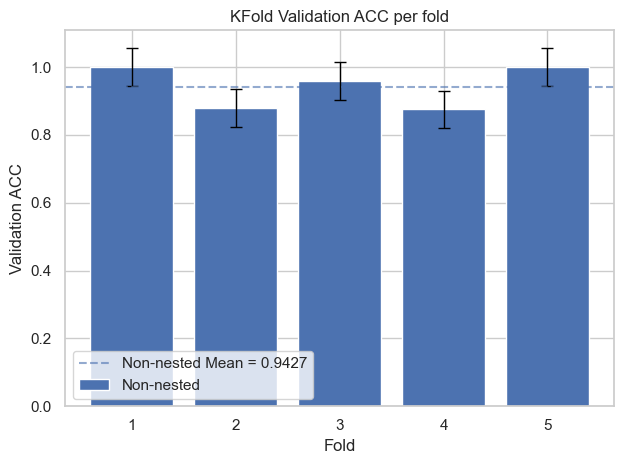

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,1.000000,1.000000,0.000000,0.00%
2,0.979381,0.880000,-0.099381,10.15%
3,1.000000,0.958333,-0.041667,4.17%
4,0.979592,0.875000,-0.104592,10.68%
5,1.000000,1.000000,0.000000,0.00%
MEAN,0.991795,0.942667,-0.049128,5.00%
STD,0.010050,0.055363,0.045792,4.68%


In [20]:
importlib.reload(cr)
for metric in ["acc"]:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_summary(fold_histories, use=metric))


<h4>Training</h4>
<p>Model is eventually trained with best hyper parameters from Optuna and assesed within KFold phase.</p>

In [21]:
importlib.reload(nnc)
model_final = copy.deepcopy(model_template)

train_kf_result = nnc.train(
    model_final, HoldOutStrategy(FeatureTargetSet(X_tr, y_tr), val_ratio=0.2), # 0.1 = 10% - 0.2 = 20%
    **inner_train_params
)

Early stopping at epoch 68 (best VL loss: 0.3840)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 500
Train           | samples: 98
Validation      | samples: 24
Batch type      | mini-batch (20)
Loss function   | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.0017898406757904646, 'weight_decay': 0.0002695703196588797, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | metric: loss,  patience: 50 , minimum delta: 0.001
----------------------------------------------------------------------------------------------------


In [22]:
epochs_kf_tr_loss = train_kf_result.epochs_tr_loss
epochs_kf_vl_loss = train_kf_result.epochs_vl_loss
epochs_kf_vl_acc = train_kf_result.epochs_vl_acc
epochs_kf_tr_acc = train_kf_result.epochs_tr_acc
epochs_kf_grad = train_kf_result.epochs_grad_norm

<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

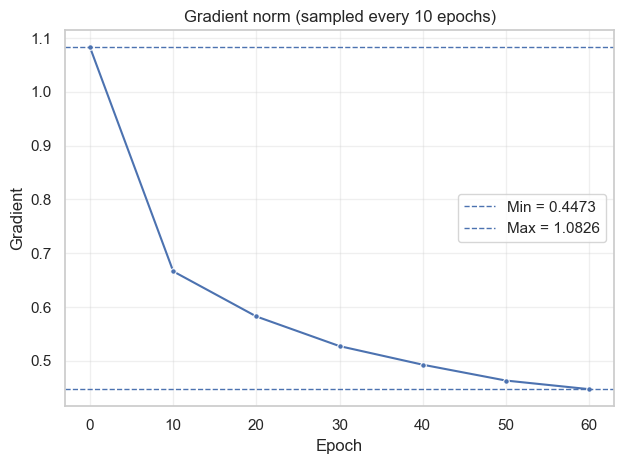

In [23]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_kf_grad, step=10)

<h5>Epoch Loss</h5>

<Figure size 640x480 with 0 Axes>

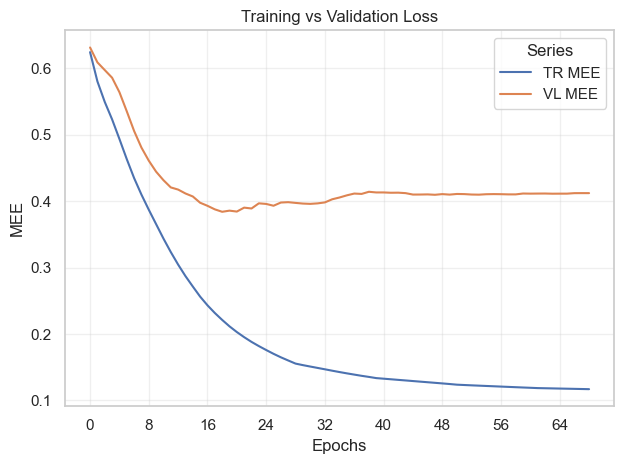

In [24]:
importlib.reload(nnc)
nnc.plot_epoch_mee(epochs_kf_tr_loss, epochs_kf_vl_loss)

In [25]:
importlib.reload(cr)
mean, std = cr.mean_std_from_kfold(epochs_kf_vl_loss)
print(f"{mean:.4f} ± {std:.4f}")

0.4256 ± 0.0540


<Figure size 640x480 with 0 Axes>

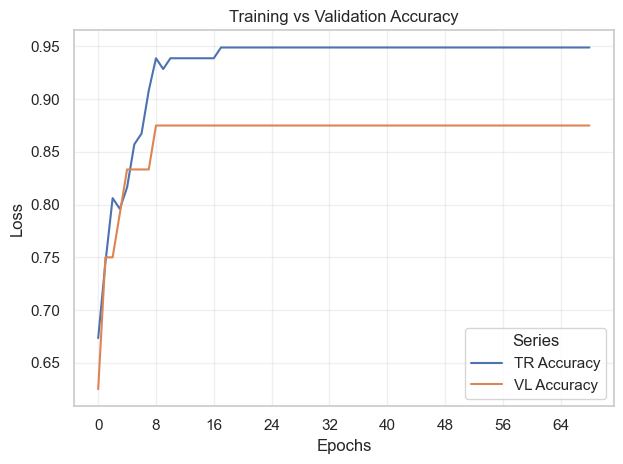

In [26]:
nnc.plot_epoch_accuracy(epochs_kf_tr_acc, epochs_kf_vl_acc)

In [27]:
from sklearn.metrics import classification_report

importlib.reload(nnc)
importlib.reload(mc)
y_pred = mc.classification_helper(model_final.predict(X_ts))
print(classification_report(y_ts, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97       204
           1       0.99      0.95      0.97       228

    accuracy                           0.97       432
   macro avg       0.97      0.97      0.97       432
weighted avg       0.97      0.97      0.97       432



<h3>Best Hyperparameters</h3>
<hr/>

In [29]:
print(f"set: {monk_data_set_id}")
for key, value in inner_train_params.items():
    print(f"{key}: {value}")

print(f"hidden layers: {final_hidden_layers}")

set: 3
epochs: 500
batch_size: 20
scheduler_template: functools.partial(<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, mode='min', factor=0.5, patience=10, threshold=0.01)
optimizer_template: functools.partial(<class 'torch.optim.adamw.AdamW'>, lr=0.0017898406757904646, weight_decay=0.0002695703196588797, betas=(0.95, 0.999))
loss_function: BCEWithLogitsLoss()
early_stopping_strategy: EarlyStopping monitoring loss with patience=50, min_delta=0.001
metrics: {'loss': (BCEWithLogitsLoss(), <built-in function min>)}
hidden layers: [24, 32]
